<h2>АЧХ и ФЧХ скользящего среднего</h2>

In [ ]:
import numpy as np
from scipy import signal
from scipy.fftpack import fftshift
import matplotlib.pyplot as plt
from  matplotlib import patches

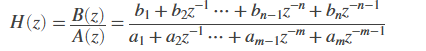

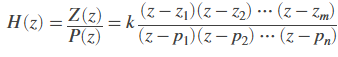

In [ ]:
def calc_filter_characteristics(num, den, M):
    # num (numerator coefficients) - коэффициенты полинома числителя фильтра
    # den (denominator coefficients) - коэффициенты полинома знаменателя фильтра
    impulse = np.concatenate(([1.], np.zeros((M - 1)), np.zeros((M // 2)))) # входной импульс (единичный)
    print("impulse: ", impulse)

    response = signal.lfilter(num, den, impulse) # реакция на единичный импульс, т.е. импульсная характеристика
    print("response: ", response)

    # w - частоты, h - H(w), комплексная частотная характеристика
    w, h = signal.freqz(num, den, whole = True, worN = 512)
    # print("w: ", w)
    # print("h: ", h)

    # z - zeroes, вектор нулей, p - poles, вектор полюсов, k - коэффициент усиления
    z, p, k = signal.tf2zpk(num, den)

    return response, w, h, z, p, k

In [ ]:
def plot_characteristics(response, w, h, z, p, k):
    fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(18, 4))

    # impulse response
    ax[0].plot(response, '-o')
    ticks = np.arange(0, len(response), 1)
    ax[0].set_xticks(ticks)
    ax[0].set(title="Импульсная характеристика (ядро фильтра)", xlabel="[n]", ylabel="Амплитуда")
    ax[0].axis('tight')

    # АЧХ
    ax[1].plot(w/np.pi - 1, 20*np.log10(np.abs(fftshift(h))), 'b')
    ax[1].grid()
    ax[1].set(title="Амплитудно-частотная характеристика", xlabel="Частота", ylabel="Амплитуда (дБ)")


    # ФЧХ
    angles = np.angle(fftshift(h))
    ax[2].plot(w/np.pi - 1, angles)
    ax[2].grid()
    ax[2].set(title="Фазо-частотная характеристика", xlabel="Частота", ylabel="Угол (радианы))")

    # нули и полюса передаточной функции на единичной окружности
    patch = patches.Circle((0,0), radius=1, fill=False, color='black', ls='dashed')
    ax[3].add_patch(patch)
    ax[3].plot(np.real(z), np.imag(z), 'ob',label='Zeros', markersize =12,  markerfacecolor='None', markeredgecolor='red')
    ax[3].plot(np.real(p), np.imag(p), 'x', label='Poles', markersize =12)
    ax[3].legend(loc=2)
    ax[3].set(title='Нули и полюса на единичной окружности',ylabel='Real',xlabel='Imaginary')
    ticks = np.arange(-1,1.5,0.5)
    ax[3].set_xticks(ticks); ax[1].set_yticks(ticks)
    ax[3].grid()

In [ ]:
M = 11
num = np.ones(M) / M
den = np.ones(1)

impulse:  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
response:  [0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909
 0.09090909 0.09090909 0.09090909 0.09090909 0.09090909 0.
 0.         0.         0.         0.        ]


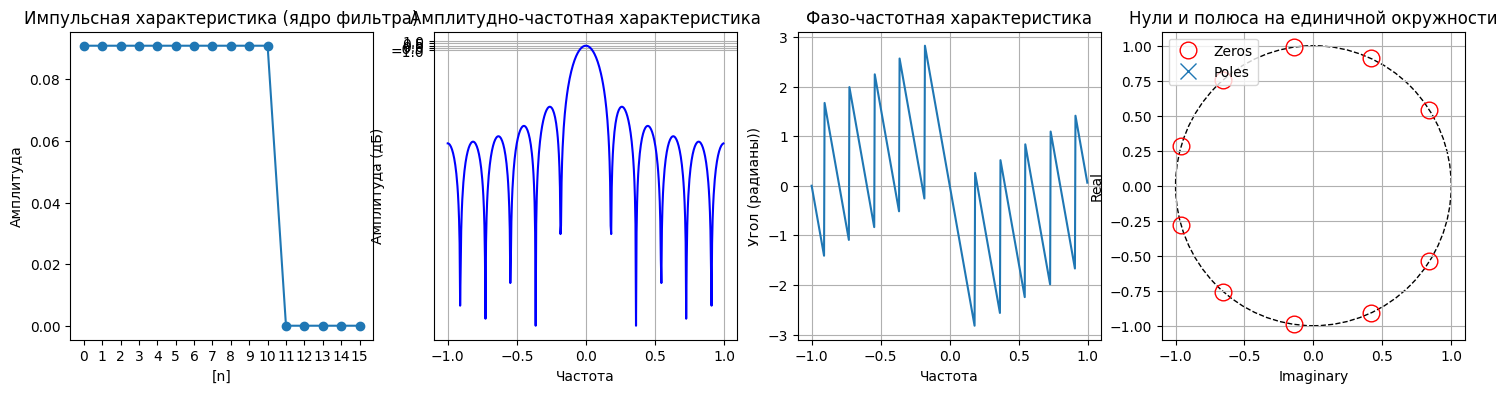

In [ ]:
response, w, h, z, p, k = calc_filter_characteristics(num, den, M)
plot_characteristics(response, w, h, z, p, k)

impulse:  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0.]
response:  [0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784 0.01960784
 0.01960784 0.01960784 0.01960784 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        

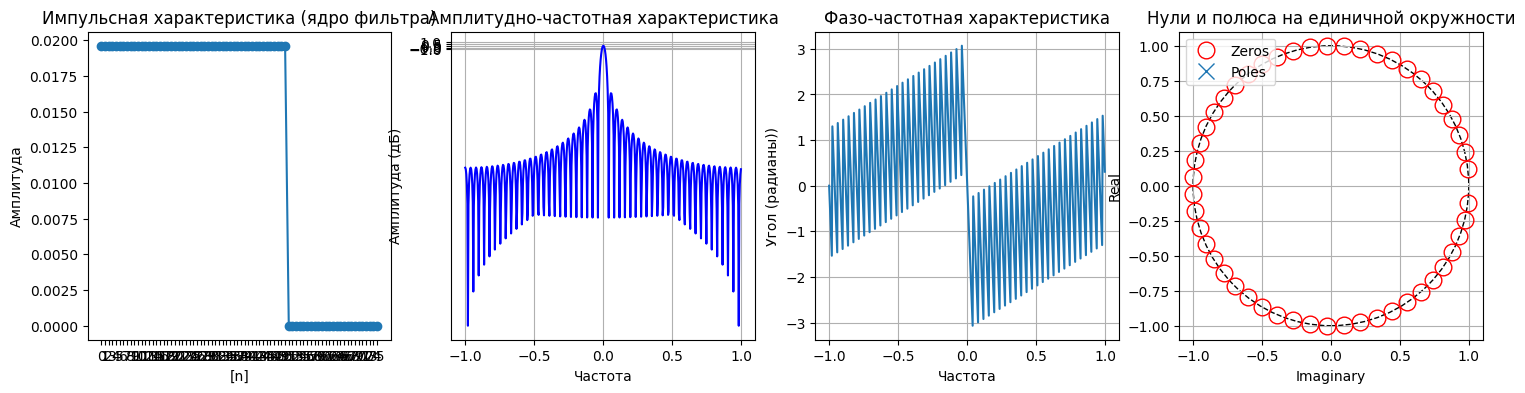

In [ ]:
M = 51
num = np.ones(M) / M
den = np.ones(1)

response, w, h, z, p, k = calc_filter_characteristics(num, den, M)
plot_characteristics(response, w, h, z, p, k)

impulse:  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
response:  [ 0.25        0.1875      0.140625   -0.45703125  0.36035156  0.23510742
 -0.83441162  0.69035339  0.38867569 -1.5213747   1.31870484  0.633681
 -2.77015851  2.51217664  1.01501697 -5.03703617]


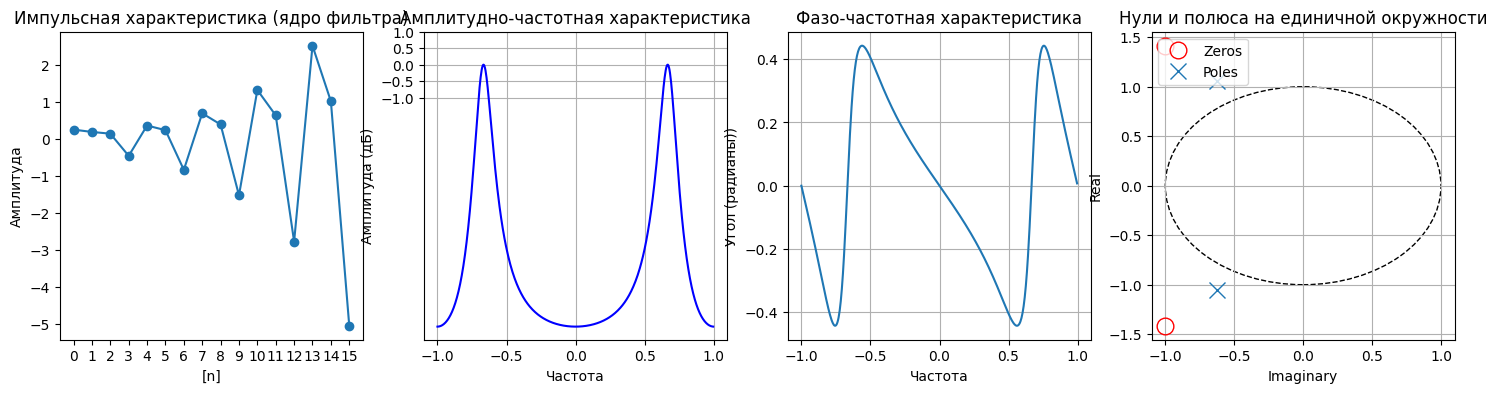

In [ ]:
num = np.asarray([1, 2, 3])
den = np.asarray([4, 5, 6])

response, w, h, z, p, k = calc_filter_characteristics(num, den, M)
plot_characteristics(response, w, h, z, p, k)

impulse:  [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
response:  [ 6.66666667e+00  8.88888889e+00  1.85185185e+01 -1.53086420e+01
  4.03292181e+00  2.41426612e+00 -2.95381802e+00  1.16445664e+00
  2.08301580e-01 -5.27019933e-01  2.81912762e-01 -1.22685303e-02
 -8.57919004e-02  6.12841104e-02 -1.22587734e-02 -1.22555212e-02]


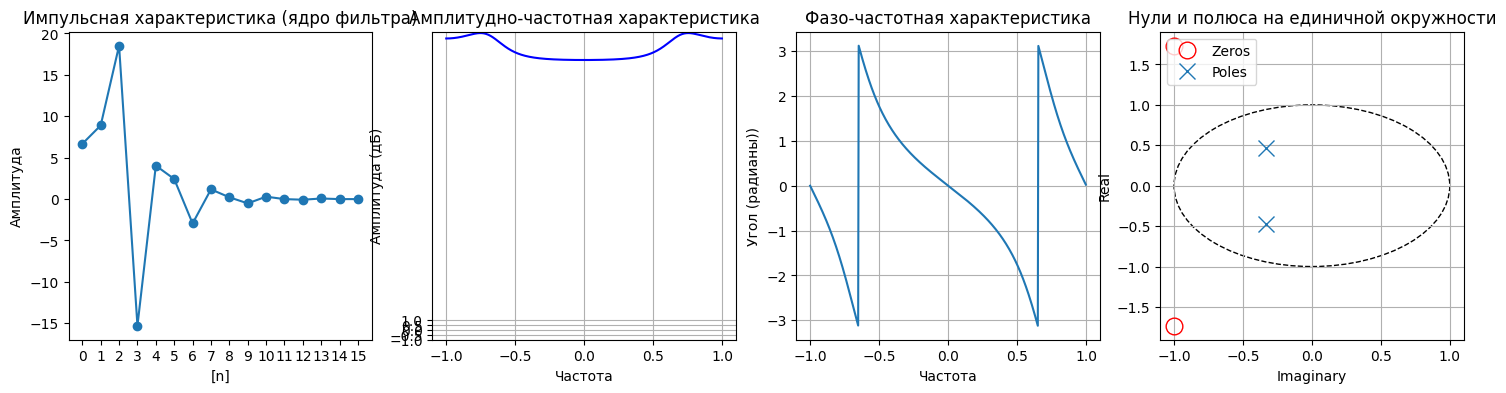

In [ ]:
num = np.asarray([1, 2, 4])
den = np.asarray([0.15, 0.1, 0.05])

response, w, h, z, p, k = calc_filter_characteristics(num, den, M)
plot_characteristics(response, w, h, z, p, k)